# Arabic Speech Emotion Recognition Model


# Used architecture

## Feature extraction: MFCC
## Model:

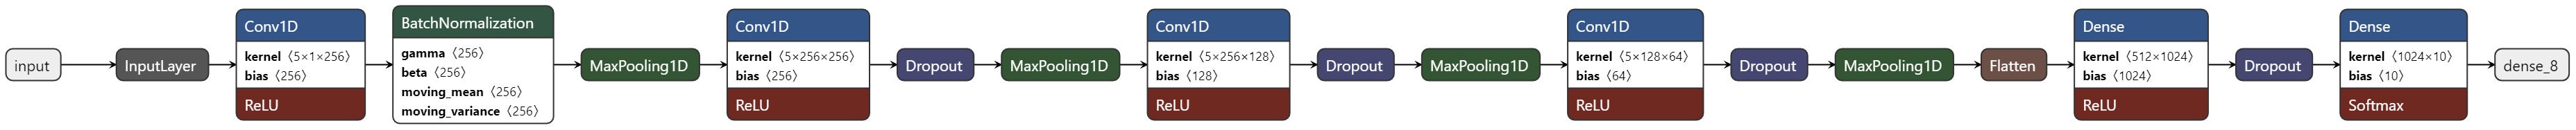

In [2]:
from IPython.display import display, Image
display(Image(filename='cnn.png'))


In [1]:
import csv
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fftpack import idct
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import time
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# Chemins vers vos dossiers
dossier_wavs = 'wavs'
dossier_noise = 'noise'
dataset = 'dataset'

### MFCC function

In [2]:
# Functions to convert between Mel and Hz scales, and to create a Hamming window

def Mel2Hz(mel): return 700 * (np.power(10, mel / 2595) - 1)
def Hz2Mel(freq): return 2595 * np.log10(1 + freq / 700)
def Hz2Ind(freq, fs, Tfft): return (freq * Tfft / fs).astype(int)
def hamming(T): return 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(T) / (T - 1))

# Mel Filter function
def FiltresMel(fs, nf=36, Tfft=512, fmin=100, fmax=8000):
    Indices = Hz2Ind(Mel2Hz(np.linspace(Hz2Mel(fmin), Hz2Mel(min(fmax, fs / 2)), nf + 2)), fs, Tfft)
    filtres = np.zeros((int(Tfft / 2), nf))
    for i in range(nf): 
        filtres[Indices[i]:Indices[i + 2], i] = hamming(Indices[i + 2] - Indices[i])
    return filtres

# Spectrogram calculation
def spectrogram(x, T, p, Tfft):
    S = [] 
    for i in range(0, len(x) - T, p): 
        S.append(x[i:i + T] * hamming(T))  # Fenêtrage
    S = np.fft.fft(S, Tfft)  # Transformée de Fourier
    return np.abs(S), np.angle(S)  # Spectre d'amplitude et de phase

# calculate MFCC 
def mfcc(data, filtres, nc=13, T=256, p=64, Tfft=512):
    data = (data[1] - np.mean(data[1])) / np.std(data[1])  # Normalisation des données
    amp, ph = spectrogram(data, T, p, Tfft)
    amp_f = np.log10(np.dot(amp[:, :int(Tfft / 2)], filtres) + 1)
    return idct(amp_f, n=nc, norm='ortho')

### Load the dataset and apply MFCC

In [4]:
# Function to extract the "spoken_emotion" from filename
def extract_classe(filename):
    parts = filename.split('-')
    if parts[0] == "noise":
        return "3"
    else:
        return parts[4]  #-------- Label assembly and return of "spoken_emotion" ----------------

#  List to store audio file paths
audio_paths = []
# List to store audio files classes
audio_classes = []
# List to store the mfcc features of audio files
mfcc_list = []

data_list = []

# Browsing speech audio files
for filename in os.listdir(dossier_wavs):
    if filename.endswith(".wav"):
        classe = extract_classe(filename)
        full_audio_path = os.path.join(dossier_wavs, filename)
        rate, signal = wavfile.read(full_audio_path)
        # Calculate MFCC only if the sampling frequency > 0
        if rate > 0:
            # Creation of mel filter
            filtres_mel = FiltresMel(rate)
            # Extraction MFCC coef
            mfcc_features = mfcc((rate, signal), filtres_mel)
            # Scaling MFCC features by calculating the mean per column
            scaled_feature = np.mean(mfcc_features.T, axis=0)
            # Converting and adding MFCC features to the list
            mfcc_list.append(scaled_feature.astype(np.float64))
            # Adding the file name, class, and MFCC features to the data list
            data_list.append([filename, classe, scaled_feature])
        else:
            print(f"Fréquence d'échantillonnage invalide pour le fichier {full_audio_path}")
        

#  Browsing Noise Audio Files
for filename in os.listdir(dossier_noise):
    if filename.endswith(".wav"):
        classe = extract_classe(filename)
        full_audio_path = os.path.join(dossier_noise, filename)
        rate, signal = wavfile.read(full_audio_path)        
        # Calculer les MFCC uniquement si la fréquence d'échantillonnage est valide (par exemple, supérieure à zéro)
        if rate > 0:
            # Création des filtres de Mel
            filtres_mel = FiltresMel(rate)
            # Extraction des coefficients MFCC
            mfcc_features = mfcc((rate, signal), filtres_mel)
            # Mise à l'échelle des caractéristiques MFCC en calculant la moyenne par colonne
            scaled_feature = np.mean(mfcc_features.T, axis=0)
            # Conversion et ajout des caractéristiques MFCC à la liste
            mfcc_list.append(scaled_feature.astype(np.float64))
            # Ajout du nom du fichier, de la classe et des caractéristiques MFCC à la liste de données
            data_list.append([filename, classe, scaled_feature])
        else:
            print(f"Fréquence d'échantillonnage invalide pour le fichier {full_audio_path}")

# # Creating pandas DataFrames
data_df = pd.DataFrame(data_list, columns=["audio_path", "classe","mfcc"])
# Stocker dans un fichier pkl
data_df.to_pickle("data.pkl")
# affichage
data_df.head()

,audio_path,classe,mfcc
0,0-m-21-0-1-105.wav,1,"[0.00017306606354571279, 0.0001730660635457127..."
1,0-m-21-0-2-106.wav,2,"[8.560349094822852e-05, 8.560349094822852e-05,..."
2,0-m-21-1-1-374.wav,1,"[8.572347994085304e-05, 8.572347994085304e-05,..."
3,0-m-21-1-2-375.wav,2,"[0.0004665245325617373, 0.0004665245325617373,..."
4,0-m-21-2-1-661.wav,1,"[0.000429678961052137, 0.000429678961052137, 0..."


### Splitting the dataset

In [3]:
# Step 1: Check the maximum length of all sequences
# This involves iterating through all sequences to determine the longest sequence length,
# which will be used for padding.

# Step 2: Pad sequences with zeros to make them the same length
# Shorter sequences are filled with zeros to match the maximum length,
# ensuring that all sequences have the same shape for processing.

# Step 3: Convert the data to PyTorch tensors
# This step involves converting the padded sequences into PyTorch tensors,
# allowing for efficient storage and computation in machine learning models.


# Loading data from the pickle file
donnees = pd.read_pickle("data.pkl")

# Checking the maximum length of all sequences
max_length = donnees["mfcc"].apply(len).max()

# Padding sequences with zeros to make them the same length
filled_sequences = donnees["mfcc"].apply(lambda x: np.pad(x, (0, max_length - len(x))))

# Converting data to PyTorch tensors
X = torch.tensor(filled_sequences.tolist(), dtype=torch.float32)
Y = torch.tensor(donnees["classe"].astype(int).tolist(), dtype=torch.int64)  

In [6]:
print(filled_sequences)

0       [0.00017306606354571279, 0.0001730660635457127...
1       [8.560349094822852e-05, 8.560349094822852e-05,...
2       [8.572347994085304e-05, 8.572347994085304e-05,...
3       [0.0004665245325617373, 0.0004665245325617373,...
4       [0.000429678961052137, 0.000429678961052137, 0...
                              ...                        
2025    [0.4302772001319068, 0.4652497644616441, 0.390...
2026    [0.4605614268284306, 0.45895840801394877, 0.40...
2027    [0.5243880402132017, 0.5217467230067251, 0.410...
2028    [0.5386681994168382, 0.5122032987401135, 0.508...
2029    [0.3663328959153418, 0.46809789660701284, 0.41...
Name: mfcc, Length: 2030, dtype: object


In [4]:
# Splitting the data into training, validation, and test sets
    # X: input features, the extracted characteristics
    # Y: output labels, containing the desired labels

train_data_x, temp_data_x, train_data_y, temp_data_y = train_test_split(
    X, Y, test_size=0.5, stratify=Y, random_state=387
)

# Splitting the temporary data into validation and test sets
validation_data_x, test_data_x, validation_data_y, test_data_y = train_test_split(
    temp_data_x, temp_data_y, test_size=0.6, stratify=temp_data_y, random_state=387
)

# Displaying the number of samples in each set
print("\nNombre d'échantillons pour l'ensemble d'entraînement :", train_data_x.shape[0])
print("Nombre d'échantillons pour l'ensemble de validation :", validation_data_x.shape[0])
print("Nombre d'échantillons pour l'ensemble de test :", test_data_x.shape[0])

# Displaying the shape of the training and test sets
print("Forme de l'ensemble d'entraînement", train_data_x.shape)
print("Forme de l'ensemble de validation", validation_data_x.shape)
print("Forme de l'ensemble de test", test_data_x.shape)

# Conversion into PyTorch tensors
train_data_x_tensor = train_data_x.unsqueeze(1)  # Ajout d'une dimension pour correspondre aux attentes du réseau
train_data_y_tensor = train_data_y.unsqueeze(1)

validation_data_x_tensor = validation_data_x.unsqueeze(1)
validation_data_y_tensor = validation_data_y.unsqueeze(1)


Nombre d'échantillons pour l'ensemble d'entraînement : 1015
Nombre d'échantillons pour l'ensemble de validation : 406
Nombre d'échantillons pour l'ensemble de test : 609
Forme de l'ensemble d'entraînement torch.Size([1015, 1276])
Forme de l'ensemble de validation torch.Size([406, 1276])
Forme de l'ensemble de test torch.Size([609, 1276])


### Model CNN - 1D 

In [18]:
# Defining the CNN1D model
class CNN_1D(nn.Module):
    def __init__(self, input_shape):
        super(CNN_1D, self).__init__()
        
        # Convolutional function - layer 1 -
        self.conv1 = nn.Conv1d(1, 256, kernel_size=5, stride=1, padding=2)  
        # Activation function 
        self.relu1 = nn.ReLU()
        # Batch normalization
        self.bn1 = nn.BatchNorm1d(256)
        # Max pooling to reduce the dimensionality of the data by taking the maximum value from each window 
            #(which contains the weights)
        self.maxpool1 = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)  
        # Convolutional function - layer 2 -
        self.conv2 = nn.Conv1d(256, 256, kernel_size=5, stride=1, padding=2)
        # Helps to prevent overfitting
        self.dropout1 = nn.Dropout(0.3)
        self.maxpool2 = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)  
         # Convolutional function - layer 3 -
        self.conv3 = nn.Conv1d(256, 128, kernel_size=5, stride=1, padding=2)  
        self.dropout2 = nn.Dropout(0.3)
        self.maxpool3 = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)  
        # Convolutional function - layer 4 -
        self.conv4 = nn.Conv1d(128, 64, kernel_size=5, stride=1, padding=2)  
        self.dropout3 = nn.Dropout(0.3)
        self.maxpool4 = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)  
        self.flatten = nn.Flatten()
        # lineaire layer 
        self.fc1 = nn.Linear(5120, 1024)
        self.relu2 = nn.ReLU()
        self.dropout4 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(1024, 4)
        # Converting raw scores to probabilities
        self.softmax = nn.Softmax(dim=1)
        
    # Forward pass phase where we apply the previous elements
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.bn1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.dropout1(x)
        x = self.maxpool2(x)
        x = self.conv3(x)
        x = self.dropout2(x)
        x = self.maxpool3(x)
        x = self.conv4(x)
        x = self.dropout3(x)
        x = self.maxpool4(x)
        x = self.flatten(x)    
        x = self.fc1(x)
        x = self.relu2(x)
        x = self.dropout4(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

# Creating DataLoaders (dividing the data)
  # Using a "mini-batch" of size 64 per block
train_dataset = TensorDataset(train_data_x_tensor, train_data_y_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

valid_dataset = TensorDataset(validation_data_x_tensor, validation_data_y_tensor)
valid_loader = DataLoader(valid_dataset, batch_size=64)

# Model creation
input_shape = train_data_x_tensor.shape[1:]
model = CNN_1D(input_shape)

# Define the loss function and the optimizer: CrossEntropyLoss
    # Note: If using CrossEntropyLoss, then no need to apply softmax beforehand
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)



# Model training
t0 = time.time()

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(200):
    model.train()  # Met le modèle en mode d'entraînement
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # 64 / 1015 ~ 15 iter
    for inputs, classes in train_loader:
        classes = classes.squeeze(1)  # Remove extra dimension 
        optimizer.zero_grad() # Reset the gradients ->
             #Note: 
                # Calling optimizer.zero_grad() is crucial during training. 
                # It resets the gradients to zero at the beginning of each iteration, 
                # preventing the accumulation of gradients from previous mini-batches. 
                # This ensures that weight updates are based solely on the current mini-batch, 
                # leading to stable and effective learning.

        outputs = model(inputs)
        loss = loss_function(outputs, classes) # Calculate loss
        loss.backward() # calculate the gradiant of the loss fct
        optimizer.step() # UPDATE wheights
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total_train += classes.size(0)
        correct_train += (predicted == classes).sum().item()
    # Loss of each epoch 
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    
    ##############################################################################################################    
    ## Evaluation on the validation data ##################################################################
    model.eval()
    correct_val = 0
    total_val = 0
    validation_loss = 0
    with torch.no_grad():
        for inputs, classes in valid_loader:
            classes = classes.squeeze(1)  # Pour enlever la dimension supplémentaire
            outputs = model(inputs)
            loss = loss_function(outputs, classes) # Calcule la perte
            validation_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += classes.size(0)
            correct_val += (predicted == classes).sum().item()
    
    val_loss = validation_loss / len(valid_loader)
    val_accuracy = 100 * correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Displaying the epoch, loss, and accuracy on the validation data
    print(f"Epoch {epoch+1}, Training Loss: {train_loss:.4f} - Training Accuracy: {train_accuracy:.4f}% - Validation Loss: {val_loss:.4f} - Validation Accuracy: {val_accuracy:.4f}%")

# Save the model
torch.save(model.state_dict(), "Model2.pth")
print("CNN1D Model Saved")

# Saving the training history
train_history = {"train_loss": train_losses, "val_loss": val_losses, "train_accuracy": train_accuracies, "val_accuracy": val_accuracies}
np.save("train_history.npy", train_history)

# Training time
train_time = round(time.time() - t0, 3)
print(f"Training time: {train_time} seconds")

Epoch 1, Training Loss: 2.1070 - Training Accuracy: 37.1429% - Validation Loss: 2.1681 - Validation Accuracy: 43.3498%
Epoch 2, Training Loss: 2.0168 - Training Accuracy: 42.9557% - Validation Loss: 2.0448 - Validation Accuracy: 44.0887%
Epoch 3, Training Loss: 2.0000 - Training Accuracy: 44.9261% - Validation Loss: 2.0072 - Validation Accuracy: 45.5665%
Epoch 4, Training Loss: 1.9649 - Training Accuracy: 49.2611% - Validation Loss: 2.0027 - Validation Accuracy: 48.0296%
Epoch 5, Training Loss: 1.9343 - Training Accuracy: 53.5961% - Validation Loss: 1.9804 - Validation Accuracy: 51.9704%
Epoch 6, Training Loss: 1.9403 - Training Accuracy: 51.2315% - Validation Loss: 2.0084 - Validation Accuracy: 46.5517%
Epoch 7, Training Loss: 1.9194 - Training Accuracy: 53.6946% - Validation Loss: 2.0533 - Validation Accuracy: 41.1330%
Epoch 8, Training Loss: 1.9613 - Training Accuracy: 49.8522% - Validation Loss: 2.0988 - Validation Accuracy: 35.7143%
Epoch 9, Training Loss: 1.9293 - Training Accura

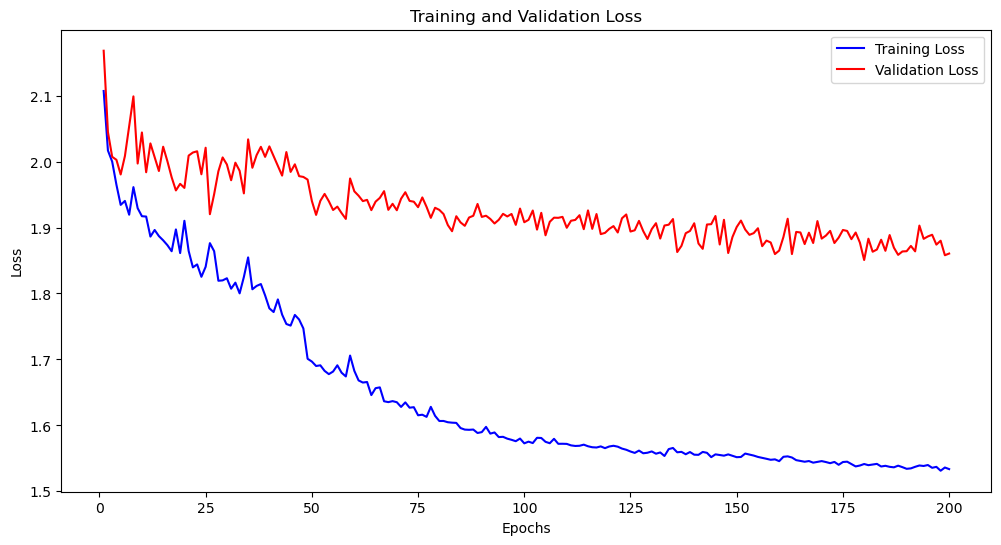

In [19]:
# Charge the training history
train_history = np.load("train_history.npy", allow_pickle=True).item()

# Extracting training and validation losses
train_losses = train_history["train_loss"]
val_losses = train_history["val_loss"]
train_accuracies = train_history["train_accuracy"]
val_accuracies = train_history["val_accuracy"]

# Nomber of epoch
epochs = range(1, len(train_losses) + 1)

# Plot for losses and accuracies
plt.figure(figsize=(12, 6))

# Plot pour les pertes
#plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b', label='Training Loss')
plt.plot(epochs, val_losses, 'r', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

#plt.tight_layout()
plt.show()

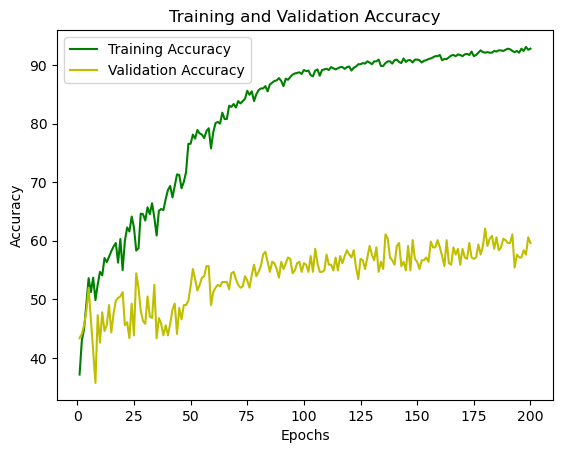

In [21]:
# Precision plot
#plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'g', label='Training Accuracy')
plt.plot(epochs, val_accuracies, 'y', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

#plt.tight_layout()
plt.show()

In [22]:
# Evaluation on the validation data
model.eval()
predicted_labels = []
true_labels = []
with torch.no_grad():
    for inputs, classes in valid_loader:
        classes = classes.squeeze(1)  # Pour enlever la dimension supplémentaire
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        predicted_labels.extend(predicted.tolist())
        true_labels.extend(classes.tolist())

# Conversion of listes into numpy table
predicted_labels = np.array(predicted_labels)
true_labels = np.array(true_labels)

# Calculating the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)
print("Matrice de confusion:")
print(conf_matrix)

Confusion Matrix:
[[94 13 10  0]
 [56 48 30  0]
 [26 29 81  0]
 [ 0  0  0 19]]


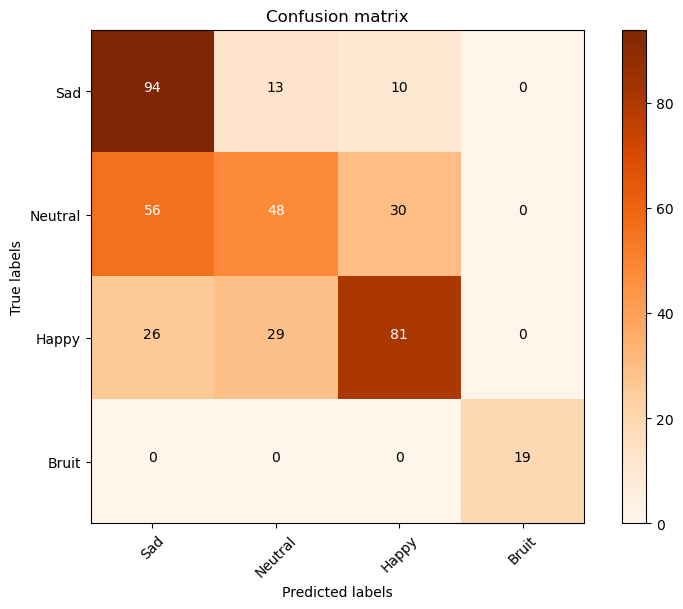

In [27]:

import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, target_names, title='Confusion matrix', cmap=None, normalize=False):
    """
    Arguments
    ---------
    cm:           Matrice de confusion

    target_names: Noms des classes

    title:        Titre de la matrice de confusion

    cmap:         La couleur à utiliser pour la heatmap

    normalize:    Si True, affiche les proportions
    """
     
    if cmap is None:
        cmap = plt.get_cmap('Oranges')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    
    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylim(len(target_names)-0.5, -0.5)
    plt.ylabel('True labels')
    plt.xlabel('Predicted labels')
    plt.savefig(title + '.png', dpi=500, bbox_inches='tight')
    plt.show()

# Loading the trained model
model = CNN_1D(input_shape)
model.load_state_dict(torch.load("Model2.pth"))
model.eval()

# Predicting the labels on the validation data
predicted_labels = []
true_labels = []
with torch.no_grad():
    for inputs, classes in valid_loader:
        classes = classes.squeeze(1)  # Pour enlever la dimension supplémentaire
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        predicted_labels.extend(predicted.tolist())
        true_labels.extend(classes.tolist())

# Calculer la matrice de confusion
target_names = ['Sad', 'Neutral', 'Happy', 'Bruit']  # Noms des classes
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Display the confusion matrix
plot_confusion_matrix(conf_matrix, target_names)


In [28]:
def calculate_metrics(conf_matrix):
    # True Positives (TP)
    TP = np.diag(conf_matrix)

    # False Positives (FP)
    FP = np.sum(conf_matrix, axis=0) - TP

    # False Negatives (FN)
    FN = np.sum(conf_matrix, axis=1) - TP

    # True Negatives (TN)
    TN = np.sum(conf_matrix) - (TP + FP + FN)

    # Accuracy
    accuracy = (TP + TN) / np.sum(conf_matrix)

    # Precision
    precision = TP / (TP + FP)

    # Recall
    recall = TP / (TP + FN)

    # F1 Score
    f1_score = 2 * (precision * recall) / (precision + recall)

    return accuracy, precision, recall, f1_score

# Calcul des métriques
accuracy, precision, recall, f1_score = calculate_metrics(conf_matrix)

# Affichage des résultats
for i, target_name in enumerate(target_names):
    print(f"Metrics for {target_name}:")
    print(f"Accuracy: {accuracy[i]:.4f}")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1 Score: {f1_score[i]:.4f}")
    print("\n")

# Micro-average et macro-average
micro_accuracy = np.mean(accuracy)
micro_precision = np.mean(precision)
micro_recall = np.mean(recall)
micro_f1_score = np.mean(f1_score)

macro_accuracy = np.mean(accuracy)
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1_score = np.mean(f1_score)

print("Micro-average metrics:")
print(f"Accuracy: {micro_accuracy:.4f}")
print(f"Precision: {micro_precision:.4f}")
print(f"Recall: {micro_recall:.4f}")
print(f"F1 Score: {micro_f1_score:.4f}")
print("\n")

print("Macro-average metrics:")
print(f"Accuracy: {macro_accuracy:.4f}")
print(f"Precision: {macro_precision:.4f}")
print(f"Recall: {macro_recall:.4f}")
print(f"F1 Score: {macro_f1_score:.4f}")


Metrics for Sad:
Accuracy: 0.7414
Precision: 0.5341
Recall: 0.8034
F1 Score: 0.6416


Metrics for Neutral:
Accuracy: 0.6847
Precision: 0.5333
Recall: 0.3582
F1 Score: 0.4286


Metrics for Happy:
Accuracy: 0.7660
Precision: 0.6694
Recall: 0.5956
F1 Score: 0.6304


Metrics for Bruit:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


Micro-average metrics:
Accuracy: 0.7980
Precision: 0.6842
Recall: 0.6893
F1 Score: 0.6751


Macro-average metrics:
Accuracy: 0.7980
Precision: 0.6842
Recall: 0.6893
F1 Score: 0.6751


### Tester le modèle

In [23]:
# Conversion en tenseurs PyTorch
test_data_x_tensor = test_data_x.unsqueeze(1)  # Ajout d'une dimension pour correspondre aux attentes du réseau

# Charger le modèle
model = CNN_1D(input_shape)
model.load_state_dict(torch.load("Model2.pth"))
model.eval()

# Effectuer la prédiction sur les données de test
with torch.no_grad():
    model.eval()  # Mettre le modèle en mode évaluation
    outputs = model(test_data_x_tensor)  # Prédire les classes des données audio de test
    _, predicted = torch.max(outputs, 1)  # Obtenir les indices des classes prédites

# Afficher les classes prédites
predicted_classes = predicted.tolist()  # Convertir en liste
print("Classes prédites pour les données de test:", predicted_classes)

# Afficher les classes réelles
true_classes = test_data_y.tolist()  # Convertir en liste
print("Classes réelles pour les données de test:", true_classes)


Classes prédites pour les données de test: [0, 1, 1, 0, 0, 2, 2, 1, 0, 0, 2, 2, 0, 1, 1, 2, 0, 1, 2, 2, 2, 1, 1, 1, 0, 0, 2, 1, 0, 2, 1, 2, 1, 0, 0, 1, 2, 0, 2, 0, 1, 0, 1, 2, 0, 0, 1, 0, 0, 1, 2, 0, 2, 2, 2, 3, 2, 1, 2, 1, 0, 2, 2, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 2, 2, 1, 0, 0, 2, 3, 0, 3, 2, 2, 3, 2, 2, 2, 0, 2, 0, 2, 0, 2, 1, 3, 2, 2, 0, 0, 2, 1, 1, 0, 1, 0, 0, 0, 1, 3, 0, 1, 2, 0, 2, 0, 0, 2, 0, 0, 0, 2, 1, 1, 2, 1, 2, 2, 1, 1, 1, 2, 2, 1, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 0, 2, 1, 1, 1, 0, 0, 3, 3, 2, 0, 2, 0, 0, 2, 2, 0, 0, 2, 0, 1, 2, 1, 1, 2, 2, 2, 2, 1, 1, 3, 1, 0, 1, 2, 2, 2, 1, 0, 2, 2, 2, 0, 2, 0, 1, 2, 0, 2, 1, 0, 2, 2, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 0, 2, 0, 0, 0, 0, 1, 2, 0, 2, 1, 2, 0, 0, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 1, 2, 0, 3, 0, 1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 0, 1, 0, 3, 2, 0, 2, 2, 2, 2, 0, 2, 2, 0, 0, 1, 1, 1, 2, 1, 2, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 3, 0, 0, 0, 1, 0, 0, 0, 2, 0, 2, 0, 0, 1, 0, 1, 1, 0, 0, 3, 2, 1, 1, 0, 1, 2, 0, 1, 2, 1, 1, 2,

In [24]:
# Calcul du nombre de prédictions incorrectes
incorrect_predictions = sum(1 for predicted, true in zip(predicted_classes, true_classes) if predicted != true)

# Calcul du taux d'erreur
error_rate = incorrect_predictions / len(true_classes) * 100

# Affichage du taux d'erreur
print(f"Taux d'erreur sur les données de test : {error_rate:.2f}%")


Taux d'erreur sur les données de test : 37.60%


# Résultats:

### Loss Function Graph:
 - Rapid decrease in loss at the beginning: The model learns effectively at the start of training.
 - Convergence of losses: Both loss lines reach a certain level of stability.
 - Absence of overfitting: The validation loss does not start to increase after the training loss has reached its minimum.

### Accuracy Graph:
 - Training accuracy (red line): It starts at a high level and increases slightly over the epochs, indicating that the model performs well and learns effectively on the training data.
 - Validation accuracy (blue line): It starts lower than the training accuracy and increases slightly throughout the epochs, suggesting that the model generalizes well to the data not used for training.

### According to the confusion matrix:
 - The model accurately recognizes "sad" and "happy."
 - It mostly confuses "sad" and "neutral."
 - Noise is recognized without error.
